# Parameter Sweep: Natural Inflation $f$

$V=\Lambda^4[1-\cos(\phi/f)]$. For every $f$, $\phi_i$ is found by root-finding on the **exact background ODE** (starting from a slow-roll quadrature guess) to hit $N_{\rm end}=65$ exactly, and $\Lambda^4$ is tuned to the shared pivot benchmark $\mathcal{P}_\mathcal{R}(k_*)=2.05\times10^{-9}$.

In [1]:
import numpy as np
from scipy import integrate
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

def background_eqn(N, fields, potential):
    phi, dphidN = fields
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
               - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    return [dphidN, d2phidN2]

def Hubble(phi_N, V):
    return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))

def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

def stop_integration(N, y):
    return 0.5*(y[1]**2) - 1
stop_integration.terminal = True
stop_integration.direction = 0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def z_of(a, phi_N):
    return a*phi_N

def solve_background(potential, ph_initial, t_end=120.0, fine_step=2e-3):
    efolds_fine = np.arange(0, t_end, fine_step)
    sol = solve_ivp(lambda N, y: background_eqn(N, y, potential),
                     [0, t_end], ph_initial, method='RK45',
                     dense_output=True, events=(stop_integration,), max_step=np.inf)
    Nend = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    mask = efolds_fine < Nend
    efolds = efolds_fine[mask]
    y = sol.sol(efolds)
    phi, dphi = y[0], y[1]
    pot, dpotdphi = potential(phi)
    Hub = Hubble(dphi, pot)
    return dict(efolds=efolds, phi=phi, dphi=dphi, pot=pot,
                dpotdphi=dpotdphi, Hub=Hub, Nend=Nend)

def pert_eqn(y, N, k, ai, potential):
    phi, dphidN, Rk_re, Rk_re_N, Rk_im, Rk_im_N, hk_re, hk_re_N, hk_im, hk_im_N = y
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    a = ai*np.exp(N)
    H = np.sqrt(v/(3 - 0.5*(dphidN*dphidN)))
    zN = a*(dphidN + d2phidN2)
    zval = z_of(a, dphidN)
    Rk_re_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_re_N - ((k/(a*H))**2)*Rk_re
    Rk_im_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_im_N - ((k/(a*H))**2)*Rk_im
    hk_re_NN = -(3 - (dphidN**2)*0.5)*hk_re_N - ((k/(a*H))**2)*hk_re
    hk_im_NN = -(3 - (dphidN**2)*0.5)*hk_im_N - ((k/(a*H))**2)*hk_im
    return [dphidN, d2phidN2, Rk_re_N, Rk_re_NN, Rk_im_N, Rk_im_NN,
            hk_re_N, hk_re_NN, hk_im_N, hk_im_NN]

def boundary(k, t, aH, Nic_cond, Nshs_cond):
    ic_diff = k - Nic_cond*aH
    shs_diff = k - Nshs_cond*aH
    idx_ic, _ = find_nearest(ic_diff, 0)
    idx_shs, _ = find_nearest(shs_diff, 0)
    return idx_ic, t[idx_ic], t[idx_shs]

def initial_condition(idx_ic, k, efolds, phi, dphi, ai, Hub, potential):
    phi_ic = phi[idx_ic]; phiN_ic = dphi[idx_ic]
    a_ic = ai*np.exp(efolds[idx_ic]); z_ic = z_of(a_ic, phiN_ic); H_ic = Hub[idx_ic]
    _, phiNN_ic = background_eqn(efolds[idx_ic], [phi_ic, phiN_ic], potential)
    Rk_re_ic = (1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic = 0
    Rk_re_N_ic = -Rk_re_ic*((phiNN_ic/phiN_ic) + 1)
    Rk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic = (1/(np.sqrt(2*k)))/a_ic
    hk_im_ic = 0
    hk_re_N_ic = -hk_re_ic
    hk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    return [phi_ic, phiN_ic, Rk_re_ic, Rk_re_N_ic, Rk_im_ic, Rk_im_N_ic,
            hk_re_ic, hk_re_N_ic, hk_im_ic, hk_im_N_ic]

def Psk(kk, Rk):
    Rk_re, Rk_im = Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_im*Rk_im))

def Pth(kk, hk):
    hk_re, hk_im = hk
    return 8.0*kk**3/(2e0*np.pi**2)*((hk_re*hk_re)+(hk_im*hk_im))

class InflationRun:
    def __init__(self, potential, bg, kpivot=0.05, Nic_cond=100, Nshs_cond=1e-5):
        self.potential = potential
        self.efolds = bg['efolds']; self.phi = bg['phi']; self.dphi = bg['dphi']
        self.Hub = bg['Hub']; self.Nend = bg['Nend']
        self.Nic_cond = Nic_cond; self.Nshs_cond = Nshs_cond
        idx50, Ne50 = find_nearest(self.efolds, self.Nend - 50)
        self.idx50, self.Ne50 = idx50, Ne50
        self.ai = kpivot/(np.exp(Ne50)*self.Hub[idx50])
        self.kpivot = kpivot

    def compute_pps(self, kk, atol=1e-11):
        idx_ic, Nic, Nshs = boundary(kk, self.efolds, self.ai*np.exp(self.efolds)*self.Hub,
                                      self.Nic_cond, self.Nshs_cond)
        efolds_pert = np.arange(Nic, Nshs, 0.01)
        pert_ic = initial_condition(idx_ic, kk, self.efolds, self.phi, self.dphi,
                                     self.ai, self.Hub, self.potential)
        sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert,
                                     args=(kk, self.ai, self.potential), atol=atol)
        Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
        hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
        return Psk(kk, Rkshs), Pth(kk, hkshs), efolds_pert, sol_pert, Nic, Nshs


In [2]:
from scipy import integrate as _integrate_module

def nat_potential(phi, Lam4, f):
    v = Lam4*(1-np.cos(phi/f))
    dv = Lam4*np.sin(phi/f)/f
    return v, dv

def eps_eta_nat(phi, f):
    return 0.5*((1.0/f)/np.tan(phi/(2*f)))**2, (1.0/f**2)*np.cos(phi/f)/(1-np.cos(phi/f))

TARGET_NEND = 65.0
TARGET_AS = 2.05e-9
KPIVOT = 0.05

def slow_roll_guess_natural(f):
    eps_fn = lambda phi: eps_eta_nat(phi, f)[0]
    phi_E = brentq(lambda p: eps_fn(p)-1, 1e-6, np.pi*f-1e-6)
    def N_of_phi(phi):
        integrand = lambda ph: 1.0/np.sqrt(2*eps_fn(ph))
        val,_ = _integrate_module.quad(integrand, phi_E, phi, limit=400)
        return val
    return brentq(lambda p: N_of_phi(p)-TARGET_NEND, phi_E+1e-8, np.pi*f-1e-8, xtol=1e-8), phi_E

def calibrate_natural(f):
    guess, phi_E = slow_roll_guess_natural(f)
    Lam4_0 = 1e-10
    pot0 = lambda phi: nat_potential(phi, Lam4_0, f)
    def Nend_of_phi(phi_i):
        ph=[phi_i, None]; V,dV = pot0(phi_i); ph[1]=-dV/V
        return solve_background(pot0, ph, t_end=150)['Nend']
    lo, hi = max(guess*0.7, phi_E*1.001), min(guess*1.3, np.pi*f*0.999)
    phi_i = brentq(lambda ph: Nend_of_phi(ph)-TARGET_NEND, lo, hi, xtol=1e-8)

    ph=[phi_i, None]; V,dV = pot0(phi_i); ph[1]=-dV/V
    bg = solve_background(pot0, ph, t_end=150, fine_step=5e-4)
    run = InflationRun(pot0, bg, kpivot=KPIVOT, Nic_cond=100)
    pps0, ppt0, *_ = run.compute_pps(KPIVOT)
    Lam4_new = Lam4_0*TARGET_AS/pps0

    pot1 = lambda phi: nat_potential(phi, Lam4_new, f)
    ph1=[phi_i, None]; V1,dV1 = pot1(phi_i); ph1[1]=-dV1/V1
    bg1 = solve_background(pot1, ph1, t_end=150, fine_step=5e-4)
    run1 = InflationRun(pot1, bg1, kpivot=KPIVOT, Nic_cond=100)
    pps1, ppt1, *_ = run1.compute_pps(KPIVOT)
    r_num = ppt1/pps1

    phi_star = bg1['phi'][run1.idx50]
    eps_v, eta_v = eps_eta_nat(phi_star, f)
    ns_analytic = 1 - 6*eps_v + 2*eta_v
    r_analytic = 16*eps_v

    return dict(f=f, phi_i=phi_i, Lam4=Lam4_new, Nend=bg1['Nend'],
                ns_analytic=ns_analytic, r_analytic=r_analytic,
                r_numerical=r_num, eps_v=eps_v, eta_v=eta_v)

## Run the sweep

In [3]:
f_values = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0, 15.0, 18.0, 20.0])
results = [calibrate_natural(f) for f in f_values]

print(f"{'f':>6} {'phi_i':>10} {'N_end':>8} {'n_s (SR)':>10} {'r (SR)':>10} {'r (num)':>10}")
for r in results:
    print(f"{r['f']:>6.1f} {r['phi_i']:>10.5f} {r['Nend']:>8.3f} {r['ns_analytic']:>10.4f} {r['r_analytic']:>10.5f} {r['r_numerical']:>10.5f}")

     f      phi_i    N_end   n_s (SR)     r (SR)    r (num)
   3.0    9.24958   65.000     0.8879    0.00391    0.00347
   4.0   11.48082   65.000     0.9314    0.02426    0.02263
   5.0   12.90114   65.000     0.9471    0.05176    0.04926
   6.0   13.78575   65.000     0.9533    0.07561    0.07267
   7.0   14.35556   65.000     0.9561    0.09383    0.09067
   8.0   14.73891   65.000     0.9575    0.10736    0.10409
  10.0   15.20220   65.000     0.9587    0.12510    0.12172
  12.0   15.45903   65.000     0.9592    0.13558    0.13217
  15.0   15.67167   65.000     0.9594    0.14461    0.14118
  18.0   15.78806   65.000     0.9595    0.14969    0.14624
  20.0   15.83850   65.000     0.9595    0.15192    0.14847


## Plots: how $n_s$, $r$, and $\phi_i$ vary with $f$

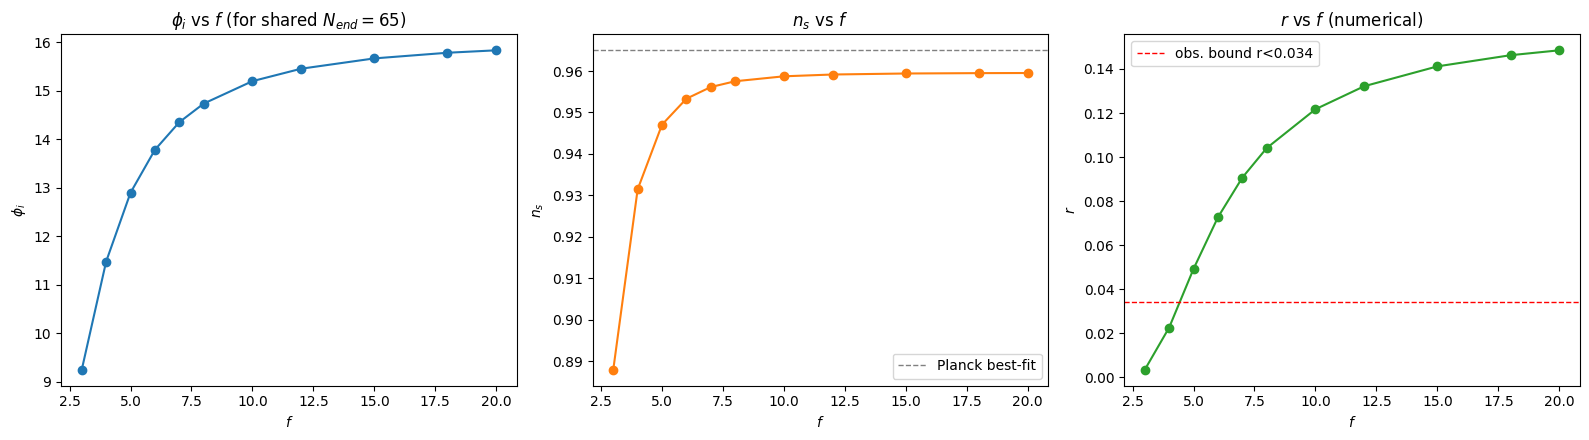

In [4]:
fs = [r['f'] for r in results]
ns_vals = [r['ns_analytic'] for r in results]
r_vals = [r['r_numerical'] for r in results]
phi_i_vals = [r['phi_i'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].plot(fs, phi_i_vals, 'o-')
axes[0].set_xlabel('$f$'); axes[0].set_ylabel(r'$\phi_i$')
axes[0].set_title(r'$\phi_i$ vs $f$ (for shared $N_{end}=65$)')

axes[1].plot(fs, ns_vals, 'o-', color='C1')
axes[1].axhline(0.965, ls='--', color='gray', lw=1, label='Planck best-fit')
axes[1].set_xlabel('$f$'); axes[1].set_ylabel('$n_s$')
axes[1].set_title('$n_s$ vs $f$'); axes[1].legend()

axes[2].plot(fs, r_vals, 'o-', color='C2')
axes[2].axhline(0.034, ls='--', color='red', lw=1, label='obs. bound r<0.034')
axes[2].set_xlabel('$f$'); axes[2].set_ylabel('$r$')
axes[2].set_title('$r$ vs $f$ (numerical)'); axes[2].legend()
plt.tight_layout(); plt.show()

## The $(n_s, r)$ track traced out by varying $f$

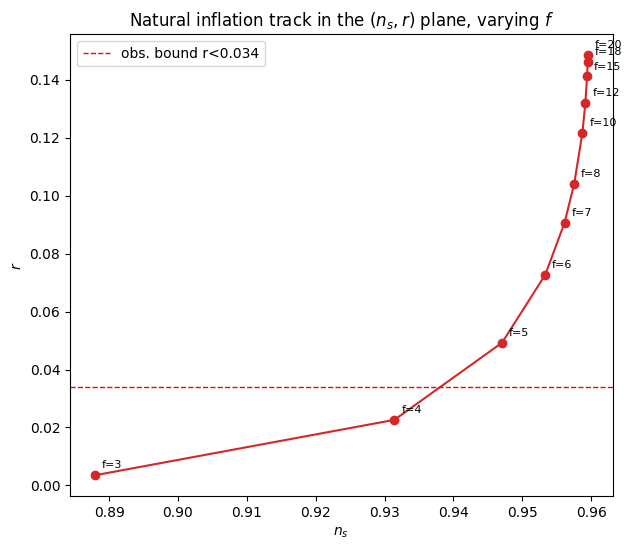

In [5]:
plt.figure(figsize=(7,6))
plt.plot(ns_vals, r_vals, 'o-', color='C3')
for r in results:
    plt.annotate(f"f={r['f']:.0f}", (r['ns_analytic'], r['r_numerical']), fontsize=8,
                 textcoords='offset points', xytext=(5,5))
plt.xlabel('$n_s$'); plt.ylabel('$r$')
plt.title('Natural inflation track in the $(n_s,r)$ plane, varying $f$')
plt.axhline(0.034, ls='--', color='red', lw=1, label='obs. bound r<0.034')
plt.legend(); plt.show()